# Практическое задание №2

## Задание
Используйте файл с информацией о ноутбуках `laptops_na.csv`.

[Источник данных](https://www.kaggle.com/datasets/bhavikjikadara/brand-laptops-dataset)


В нём содержаться следующие переменные:

- `brand`: Название бренда ноутбука.
- `Model`: Конкретная модель или серия ноутбука.
- `Price`: Цена ноутбука в индийских рупиях.
- `Rating`: Рейтинг, присвоенный ноутбуку на основе его характеристик.
- `processor_brand`: Марка процессора, используемого в ноутбуке.
- `processor_tier`: Уровень производительности или категория процессора.
- `num_cores`: Количество вычислительных ядер в процессоре.
- `num_threads`: Количество потоков, поддерживаемых процессором.
- `ram_memory`: Объем оперативной памяти, используемый в ноутбуке.
- `primary_storage_type`: Тип основного хранилища (например, HDD, SSD).
- `primary_storage -apacity`: Емкость основного хранилища ноутбука.
- `secondary_storage_type`: Тип вторичного хранилища, если оно доступно.
- `secondary_storage_capacity`: Емкость вторичного хранилища ноутбука.
- `gpu_brand`: Марка графического процессора (GPU).
- `gpu_type`: Тип графического процессора.
- `is_touch_screen`: Указывает, оснащен ли ноутбук функцией сенсорного экрана.
- `display_size`: Размер дисплея ноутбука в дюймах.
- `resolution_width`: Разрешение по ширине дисплея.
- `resolution_height`: Разрешение дисплея по высоте.
- `OS`: Установленная на ноутбуке операционная система.
- `year_of_warranty`: Срок гарантии, предоставляемой на ноутбук, обычно в годах.

Обратите внимание, что все пункты задания должны сопровождаться _выполненным_ фрагментом кода!

In [1]:
import pandas as pd
from scipy import stats
from math import sqrt
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, norm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('laptops_na.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       933 non-null    float64
 1   brand                       944 non-null    object 
 2   Model                       946 non-null    object 
 3   Price                       942 non-null    float64
 4   Rating                      936 non-null    float64
 5   processor_brand             930 non-null    object 
 6   processor_tier              950 non-null    object 
 7   num_cores                   958 non-null    float64
 8   num_threads                 953 non-null    float64
 9   ram_memory                  942 non-null    float64
 10  primary_storage_type        932 non-null    object 
 11  primary_storage_capacity    928 non-null    float64
 12  secondary_storage_type      946 non-null    object 
 13  secondary_storage_capacity  942 non

### Задание 1. Проверка отличия распределения от «нормального»

Проанализируйте распределение значений 5-ти любых метрических переменных. Проведите тест для проверки того отличается ли распределение значений переменных от нормального распределения. Сформулируйте гипотезы и выводы по результатам анализа. Постройте гистограммы распределения с наложенной кривой нормального распределения.

Проанализируем: Price, Rating, num_cores, num_threads, ram_memory.

Сделаем предварительный описательный анализ:

In [11]:
stats.shapiro(df['Price'].dropna())

ShapiroResult(statistic=np.float64(0.7374442998537247), pvalue=np.float64(4.3432229060016456e-36))

H0: Распределение значений переменной "Price" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "Price" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value = 4.34e-36 < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального.

<Axes: xlabel='Price', ylabel='Density'>

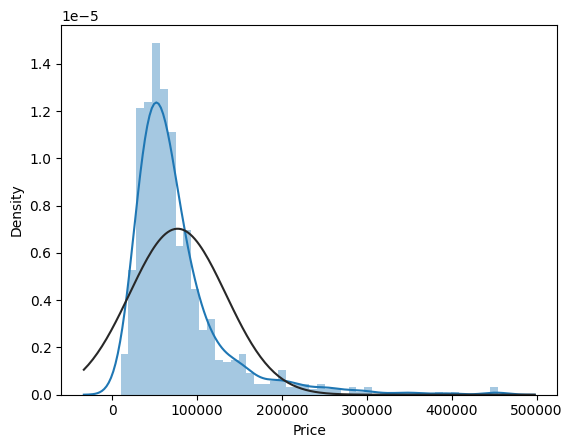

In [19]:
sns.distplot(df['Price'].dropna(), fit=norm)

In [13]:
stats.shapiro(df['Rating'].dropna())

ShapiroResult(statistic=np.float64(0.9909340982878817), pvalue=np.float64(1.609500768482758e-05))

H0: Распределение значений переменной "Rating" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "Rating" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value = 1.61e-05 < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального.

<Axes: xlabel='Rating', ylabel='Density'>

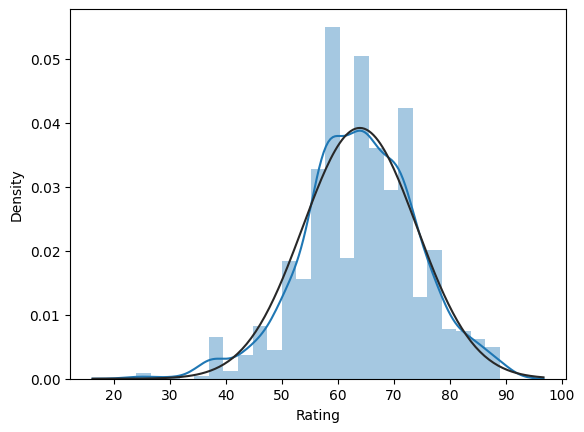

In [20]:
sns.distplot(df['Rating'].dropna(), fit=norm)

In [14]:
stats.shapiro(df['num_cores'].dropna())

ShapiroResult(statistic=np.float64(0.9054733692282457), pvalue=np.float64(6.951565000764302e-24))

H0: Распределение значений переменной "num_cores" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "num_cores" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value = 6.95e-24 < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального.

<Axes: xlabel='num_cores', ylabel='Density'>

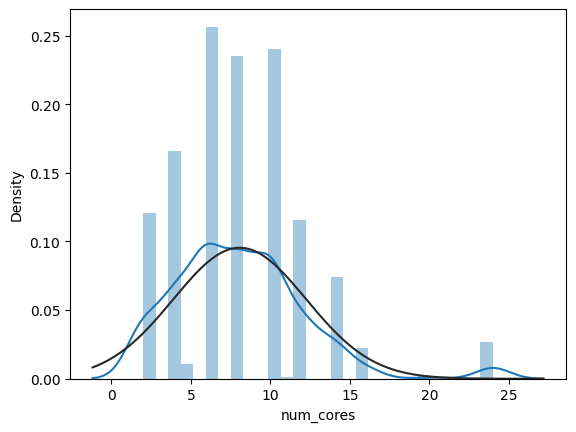

In [21]:
sns.distplot(df['num_cores'].dropna(), fit=norm)

In [15]:
stats.shapiro(df['num_threads'].dropna())

ShapiroResult(statistic=np.float64(0.9107111489078454), pvalue=np.float64(3.284676189655623e-23))

H0: Распределение значений переменной "num_threads" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "num_threads" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value = 3.28e-23 < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального.

<Axes: xlabel='num_threads', ylabel='Density'>

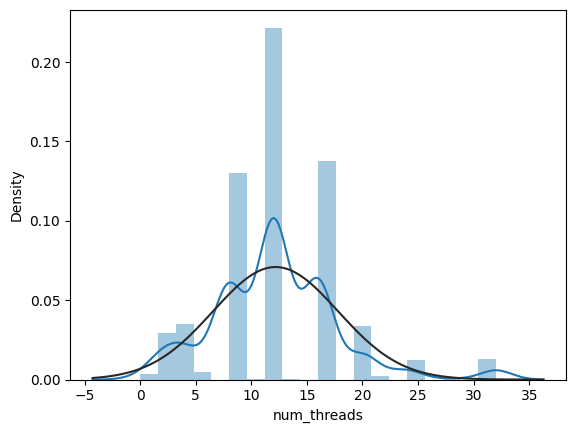

In [22]:
sns.distplot(df['num_threads'].dropna(), fit=norm)

In [23]:
stats.shapiro(df['ram_memory'].dropna())

ShapiroResult(statistic=np.float64(0.7238239854817761), pvalue=np.float64(8.965060617364125e-37))

H0: Распределение значений переменной "ram_memory" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "ram_memory" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value = 8.97e-37 < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального.

<Axes: xlabel='ram_memory', ylabel='Density'>

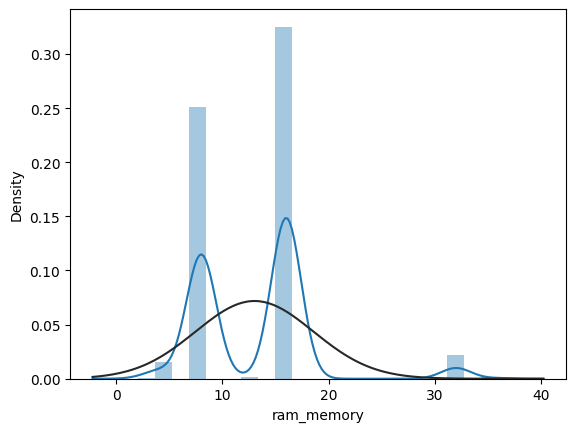

In [24]:
sns.distplot(df['ram_memory'].dropna(), fit=norm)

### Задание 2. Тест Хи-квадрат

Проведите тест Хи-квадрат не менее, чем с двумя парами переменных, для которых он применим. Можно использовать как исходные переменные, так и перекодировать их. Постройте для выбранных пар переменных таблицы сопряженности и прокомментируйте их. Сформулируйте гипотезы. Интерпретируйте результаты анализа. Обоснуйте свои выводы. Визуализируйте наблюдаемые тенденции на подходящих графиках.

Целевой сегмент и Тип видеокарты



In [71]:
# Создадим новый столбец 'price_category'
df['price_category'] = np.where(df['Price'] > df['Price'].median(), 'Premium', 'Budget')
ct1 = pd.crosstab(df['price_category'], df['gpu_type'])
ct1

gpu_type,apple,dedicated,integrated
price_category,,,
Budget,0,82,420
Premium,14,252,173


In [72]:
stats.chi2_contingency(ct1)

Chi2ContingencyResult(statistic=np.float64(200.0879048551575), pvalue=np.float64(3.560110786415142e-44), dof=2, expected_freq=array([[  7.46865037, 178.18065887, 316.35069075],
       [  6.53134963, 155.81934113, 276.64930925]]))

Все ячейки имеют частоту больше 5 -> тест Хи-квадрат применим

In [73]:
print('chi2 = ', stats.chi2_contingency(ct1)[0], '   p-value =', stats.chi2_contingency(ct1)[1])

chi2 =  200.0879048551575    p-value = 3.560110786415142e-44


H0: Отсутствует взаимосвязь между ценовым сегментом и типом видеокарты в ноутбуках

H1: Существует взаимосвязь между ценовым сегментом и типом видеокарты в ноутбуках

p-value = 3.56e-44 < 0.05 (стандартный уровень значимости - 5%)

p-value = 3.56e-44 < 0.01

Гипотеза H1 принимается на уровне значимости 1%

<Axes: xlabel='gpu_type', ylabel='price_category'>

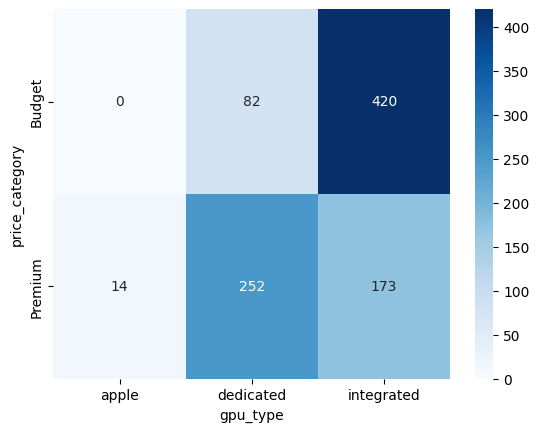

In [74]:
sns.heatmap(ct1, annot=True, cmap='Blues', fmt='d')

Премиум-ноутбуки значительно чаще оснащаются дискретными видеокартами по сравнению с бюджетными моделями, в то время как техника Apple встречается исключительно в премиум-сегменте.

Тип видеокарты и Наличие сенсорного экрана

In [29]:
ct2 = pd.crosstab(df['gpu_type'], df['is_touch_screen'])
ct2

is_touch_screen,False,True
gpu_type,,
apple,14,0
dedicated,309,9
integrated,495,72


In [30]:
stats.chi2_contingency(ct2)

Chi2ContingencyResult(statistic=np.float64(25.60882919167814), pvalue=np.float64(2.7486117392588077e-06), dof=2, expected_freq=array([[ 12.73859844,   1.26140156],
       [289.34816463,  28.65183537],
       [515.91323693,  51.08676307]]))

Ячеек с чатотой меньше 5 всего одна - это меньше 5% -> тест Хи-квадрат применим

In [32]:
print('chi2 = ', stats.chi2_contingency(ct2)[0], '   p-value =', stats.chi2_contingency(ct2)[1])

chi2 =  25.60882919167814    p-value = 2.7486117392588077e-06


H0: Отсутствует взаимосвязь между типом видеокарты и наличием сенсорного экрана в ноутбуках

H1: Существует взаимосвязь между типом видеокарты и наличием сенсорного экрана в ноутбуках

p-value = 2.75e-06 < 0.05 (стандартный уровень значимости - 5%)

p-value = 2.75e-06 < 0.01

Гипотеза H1 принимается на уровне значимости 1%

<Axes: xlabel='is_touch_screen', ylabel='gpu_type'>

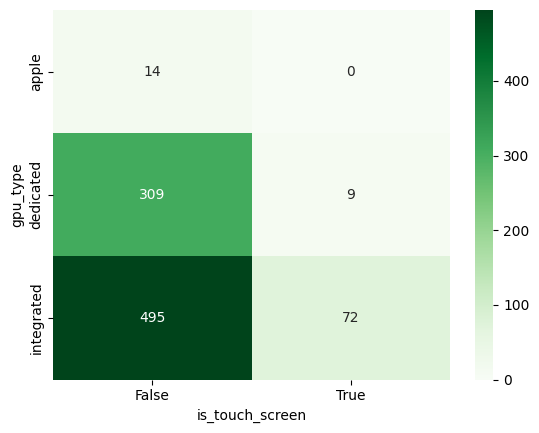

In [61]:
sns.heatmap(ct2, annot=True, cmap='Greens', fmt='d')

Ноутбуки с интегрированной графикой значительно чаще оснащаются сенсорными экранами по сравнению с ноутбуками на дискретных видеокартах, тогда как среди устройств Apple сенсорные экраны полностью отсутствуют.

### Задание 3. Парная корреляция

Проведите корреляционный анализ переменных (нужно рассмотреть не менее трёх разных пар переменных). Обоснуйте выбор рассчитываемых коэффициентов корреляции. Сформулируйте гипотезы. Визуализируйте наблюдаемые тенденции на подходящих графиках. Интерпретируйте результаты анализа (статистическая значимость, сила и направление взаимосвязи). Заполните таблицу (не менее 3 записей).

| Анализируемые пары переменных | Выбранный коэффициент корреляции (обоснование выбора) | Гипотезы | Сила взаимосвязи | Направление взаимосвязи | Статистическая значимость взаимосвязи |
| --- | --- | --- | --- | --- | --- |
| --- | --- | --- | --- | --- | --- |
| --- | --- | --- | --- | --- | --- |
| --- | --- | --- | --- | --- | --- |


Рассмотрим такие пары:
- Price и Rating - рыночная зависимость
- num_cores и num_threads - техническая зависимость
- Price и num_cores - ценовая зависимость

Price и Rating

<Axes: xlabel='Price', ylabel='Rating'>

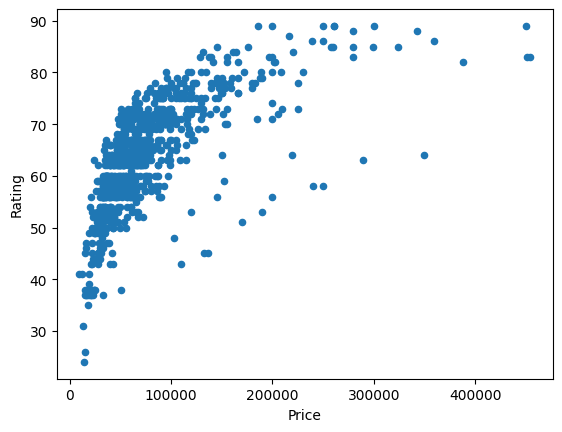

In [81]:
df.plot('Price', 'Rating', kind='scatter')

По графику видно, что имеется линейная взаимосвязь между переменными. Используем Коэффициент корреляции Спирмена, т.к. Price - метрическая переменная и имеет не нормальное распределение (цены обычно имеют правостороннее асимметричное распределение), Rating - порядковая переменная

Гипотезы:

H0: нет взаимосвязи между ценой и рейтингом товаров (r = 0)

H1: существует взаимосвязь между ценой и рейтингом товаров (r != 0)

In [82]:
df1 = df.dropna(subset=['Price', 'Rating'])
# удаление наблюдений, содержащих пропуски хотя бы по одной из анализируемых переменных
stats.spearmanr(df1['Price'], df1['Rating'])

SignificanceResult(statistic=np.float64(0.7640121937328099), pvalue=np.float64(8.608548697310834e-171))

Результаты анализа:

Статистическая значимость взаимосвязи: поскольку p-value = 8.61e-171 < 0.05, гипотеза H1 подтвердилась. Взаимосвязь статистически значима.

Направление взаимосвязи: коэффициент корреляции положительный (0.764), следовательно, между переменными наблюдается прямая взаимосвязь - с ростом цены увеличиваться рейтинг.

Сила взаимосвязи: коэффициент корреляции равен 0.764, что указывает на сильную положительную корреляцию между ценой и рейтингом товаров.

Вывод: Полученные результаты свидетельствуют о том, что более дорогие товары получать более высокие рейтинги, причем эта взаимосвязь является статистически значимой и достаточно сильной.

<Axes: xlabel='Price', ylabel='Rating'>

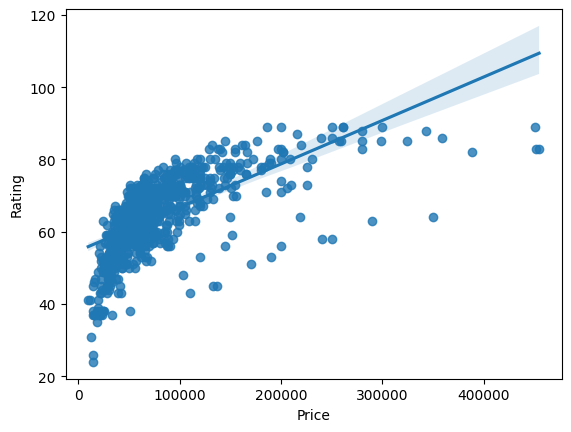

In [83]:
sns.regplot(data = df1, x = 'Price', y = 'Rating')

num_cores и num_threads

<Axes: xlabel='Price', ylabel='Rating'>

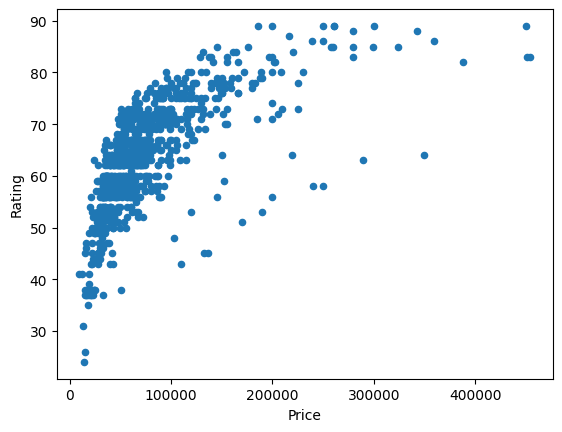

In [84]:
df.plot('Price', 'Rating', kind='scatter')

По графику видно, что имеется линейная взаимосвязь между переменными. Используем Коэффициент корреляции Спирмена, т.к. num_cores и num_threads являются метрическими, распределения их значений не отличаются от нормального. Поэтому для оценки взаимосвязи между ними мы можем рассчитать коэффициент корреляции Пирсона.

Гипотезы:

H0: нет линейной взаимосвязи между количеством ядер и количеством потоков процессора (r = 0)

H1: существует линейная взаимосвязь между количеством ядер и количеством потоков процессора (r != 0)

In [86]:
# Создаем подвыборку только с нужными столбцами
df1 = df[['num_cores', 'num_threads']].dropna()
# Теперь вычисляем корреляцию
stats.pearsonr(df1['num_cores'], df1['num_threads'])

PearsonRResult(statistic=np.float64(0.9059516632284731), pvalue=np.float64(0.0))

Результаты анализа:

Статистическая значимость взаимосвязи: поскольку p-value = 0.0 < 0.05, гипотеза H1 подтвердилась. Взаимосвязь статистически значима.

Направление взаимосвязи: коэффициент корреляции положительный (0.906), следовательно, между переменными наблюдается прямая взаимосвязь - с увеличением количества ядер увеличивается количество потоков.

Сила взаимосвязи: коэффициент корреляции равен 0.906, что указывает на очень сильную положительную линейную корреляцию между количеством ядер и потоков процессора.

Вывод: Полученные результаты свидетельствуют о практически линейной зависимости между количеством ядер и потоков в процессорах. Это ожидаемо, поскольку архитектурно количество потоков обычно прямо зависит от количества ядер.

Text(0.5, 1.0, 'Pearson correlation')

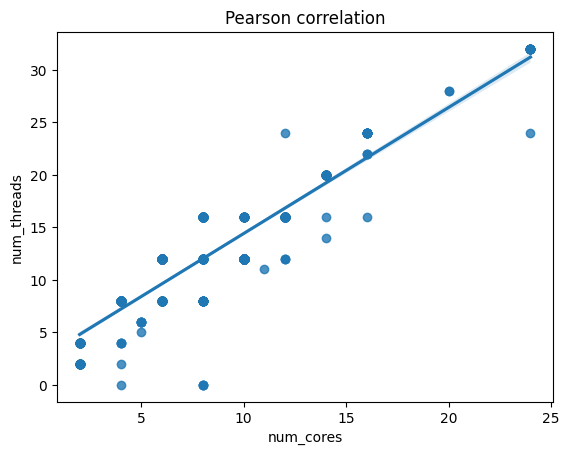

In [87]:
sns.regplot(df, x = 'num_cores', y = 'num_threads').set_title('Pearson correlation')

Price и num_cores

<Axes: xlabel='Price', ylabel='num_cores'>

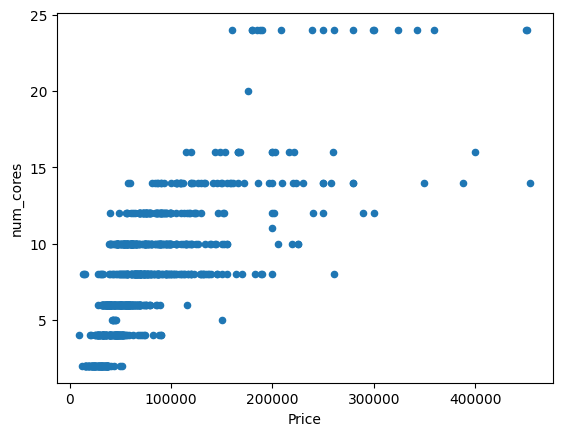

In [88]:
df.plot('Price', 'num_cores', kind='scatter')

По графику видно, что имеется линейная взаимосвязь между переменными. Используем Коэффициент корреляции Спирмена, т.к. Price - метрическая переменная и имеет не нормальное распределение (цены обычно имеют правостороннее асимметричное распределение), num_cores - дискретная метрическая переменная. Связь между ценой и количеством ядер может быть не строго линейной (цена растет не пропорционально количеству ядер)

Гипотезы:

H0: нет взаимосвязи между ценой и количеством ядер процессора (r = 0)

H1: существует взаимосвязь между ценой и количеством ядер процессора (r != 0)

In [89]:
df1 = df.dropna(subset=['Price', 'num_cores'])
# удаление наблюдений, содержащих пропуски хотя бы по одной из анализируемых переменных
stats.spearmanr(df1['Price'], df1['num_cores'])

SignificanceResult(statistic=np.float64(0.7710110147576943), pvalue=np.float64(6.024083205766511e-180))

Результаты анализа:

Статистическая значимость взаимосвязи: поскольку p-value = 6.02e-180 < 0.05, гипотеза H1 подтвердилась. Взаимосвязь статистически значима.

Направление взаимосвязи: коэффициент корреляции положительный (0.771), следовательно, между переменными наблюдается прямая взаимосвязь - с увеличением количества ядер процессора увеличивается цена товара.

Сила взаимосвязи: коэффициент корреляции равен 0.771, что указывает на сильную положительную корреляцию между ценой и количеством ядер процессора.

Вывод: Полученные результаты свидетельствуют о том, что товары с более мощными процессорами (с большим количеством ядер) иметь более высокую цену, причем эта взаимосвязь является статистически значимой и сильной.

<Axes: xlabel='Price', ylabel='num_cores'>

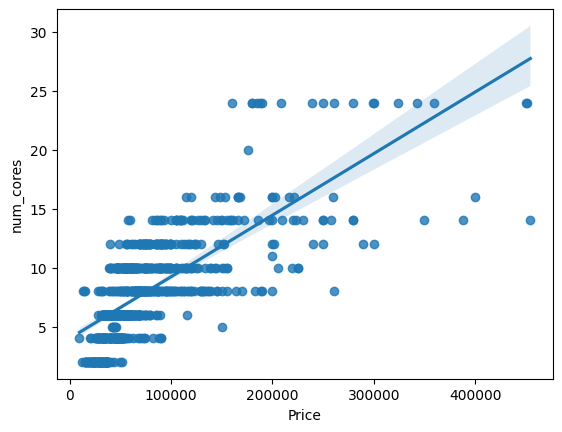

In [90]:
sns.regplot(data = df1, x = 'Price', y = 'num_cores')

### Задание 4. Частная корреляция
Посчитайте парный коэффициент корреляции между выбранной парой переменных. Посчитайте частный коэффициент корреляции между этими переменными, исключив влияние любой третьей переменной. Сделайте выводы. Визуализируйте наблюдаемые тенденции на подходящих графиках.

Для анализа частной корреляции выберу следующие переменные:
- Price (Цена) - зависимая переменная
- Rating (Рейтинг) - основная независимая переменная
- ram_memory (Оперативная память) - третья переменная для исключения влияния

Рассчитаем парный коэффициент корреляции между Price и Rating, используем Коэффициент корреляции Спирмена (обоснование в №3)

In [91]:
df1 = df.dropna(subset=['Price', 'Rating'])
stats.spearmanr(df1['Price'], df1['Rating'])

SignificanceResult(statistic=np.float64(0.7640121937328099), pvalue=np.float64(8.608548697310834e-171))

Теперь проконтролируем влияние на эту корреляцию переменной ram_memory

In [94]:
df = df.dropna(subset=['ram_memory', 'Price', 'Rating'])
r_xy = stats.pearsonr(df['Price'], df['Rating'])[0]
r_xz = stats.pearsonr(df['Price'], df['ram_memory'])[0]
r_yz = stats.pearsonr(df['Rating'], df['ram_memory'])[0]
r_xy_z = (r_xy - r_xz * r_yz) / sqrt((1 - r_xz ** 2) * (1 - r_yz ** 2))
print('Парный коэффициент корреляции между Price и Rating: ',r_xy)
print('Частный коэффициент корреляции между Price и Rating, с исключением влияния ram_memory: ',r_xy_z)

Парный коэффициент корреляции между Price и Rating:  0.6504536164157492
Частный коэффициент корреляции между Price и Rating, с исключением влияния ram_memory:  0.42113166638383775


Можно сделать вывод, что корреляция между ценой ноутбуков и их рейтингом существенно уменьшилась после того, как мы исключили влияние на их взаимосвязь переменной, характеризующей объем оперативной памяти.

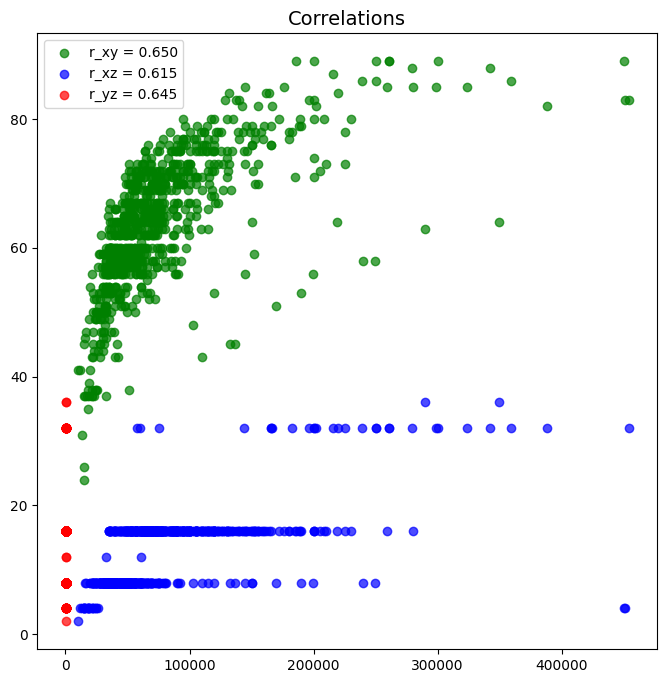

In [95]:
plt.figure(figsize=(8, 8))

plt.scatter(df['Price'], df['Rating'], c='g', alpha=0.7, label=f'r_xy = {r_xy:.3f}')
plt.scatter(df['Price'], df['ram_memory'], c='b', alpha=0.7, label=f'r_xz = {r_xz:.3f}')
plt.scatter(df['Rating'], df['ram_memory'], c='r', alpha=0.7, label=f'r_yz = {r_yz:.3f}')
plt.title(f'Correlations', fontsize=14)
plt.legend()
plt.show()

**Комментарии к заданию и принципам его оценивания:**

- Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
- Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
- Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение методов оценки взаимосвязей между переменными и их применение для анализа данных, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях инструментов.
- В этом задании четыре пункта. Каждый из них весит 25%.
- Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
- В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.
- В случае использования в работе ИИ необходимо указать где и как именно он использовался.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 14 октября.

- При сдаче работы до 23:55 15 октября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 16 октября вычитаются 2 балла из итоговой оценки.
- После **23:55 16 октября** работа не принимается.